In [1]:
import numpy as np 
from numpy.random import normal
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

#### Parametric Density Estimation

In [2]:
sample = normal(loc=50, scale=5, size=1000) # these are population parameters not the sample parameters.

sample

array([49.21741381, 51.49620518, 44.93890872, 53.70813829, 48.7284824 ,
       45.96533158, 45.8083613 , 38.00904074, 51.92959831, 50.97357581,
       55.35817026, 44.75599847, 45.89329235, 48.42808256, 47.61244619,
       48.29099248, 43.30849992, 55.23929434, 45.57112174, 47.46777847,
       51.39306564, 49.23261411, 52.39590467, 58.34000584, 58.47221356,
       55.15071696, 50.45788081, 53.54207248, 49.78909908, 48.16774757,
       55.42274694, 48.29942352, 51.92498984, 59.04422859, 52.44354618,
       37.57757644, 50.01868686, 54.20780509, 61.6708855 , 52.04178307,
       51.58202599, 50.19000803, 44.26135303, 55.0699047 , 53.2886136 ,
       42.95158478, 52.25878643, 41.55395506, 50.38957975, 49.06670608,
       51.73485496, 50.96250747, 48.50222781, 59.29077507, 56.65559995,
       50.09961443, 55.58654989, 51.11754282, 44.57304998, 53.00729895,
       59.48594906, 52.36573432, 46.14552618, 51.92056457, 47.53945367,
       53.49970274, 53.75138317, 47.47865307, 48.01015045, 54.97

In [3]:
sample.mean()

np.float64(50.22104348415424)

In [4]:
sample.std()

np.float64(5.023299996476392)

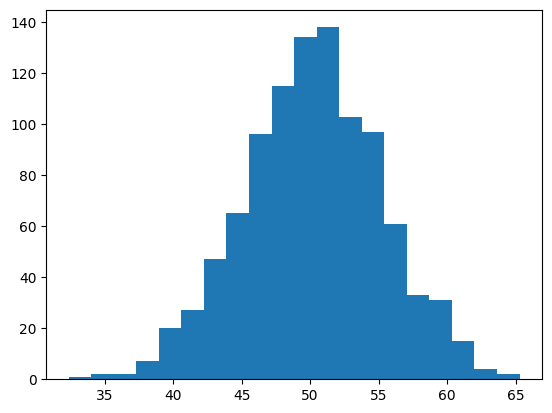

In [5]:
plt.hist(sample,bins=20);

In [6]:
sample_mean = sample.mean()
sample_std = sample.std()

In [7]:
# fit the distribution in above parameters
from scipy.stats import norm
dist = norm(sample_mean, sample_std)

In [8]:
values = np.linspace(sample.min(), sample.max(), 100)
values

array([32.38164647, 32.71392181, 33.04619714, 33.37847247, 33.71074781,
       34.04302314, 34.37529847, 34.7075738 , 35.03984914, 35.37212447,
       35.7043998 , 36.03667514, 36.36895047, 36.7012258 , 37.03350114,
       37.36577647, 37.6980518 , 38.03032714, 38.36260247, 38.6948778 ,
       39.02715313, 39.35942847, 39.6917038 , 40.02397913, 40.35625447,
       40.6885298 , 41.02080513, 41.35308047, 41.6853558 , 42.01763113,
       42.34990647, 42.6821818 , 43.01445713, 43.34673246, 43.6790078 ,
       44.01128313, 44.34355846, 44.6758338 , 45.00810913, 45.34038446,
       45.6726598 , 46.00493513, 46.33721046, 46.66948579, 47.00176113,
       47.33403646, 47.66631179, 47.99858713, 48.33086246, 48.66313779,
       48.99541313, 49.32768846, 49.65996379, 49.99223913, 50.32451446,
       50.65678979, 50.98906512, 51.32134046, 51.65361579, 51.98589112,
       52.31816646, 52.65044179, 52.98271712, 53.31499246, 53.64726779,
       53.97954312, 54.31181846, 54.64409379, 54.97636912, 55.30

In [9]:
density_probabilites = [dist.pdf(value) for value in values]

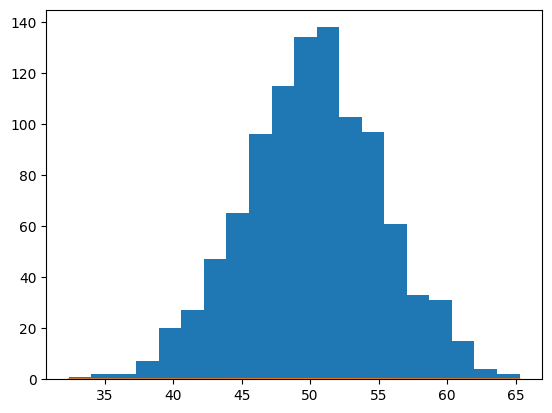

In [12]:
plt.hist(sample, bins=20)
plt.plot(values, density_probabilites)

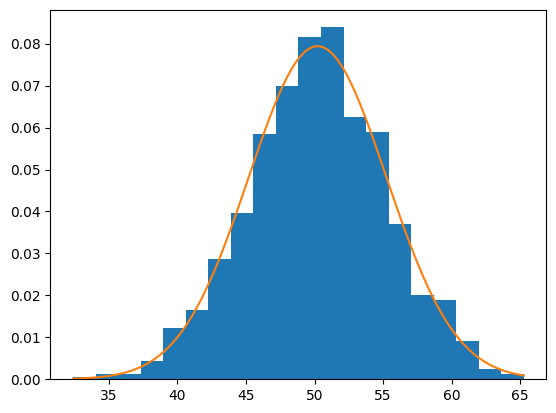

In [13]:
plt.hist(sample, bins=20, density=True)
plt.plot(values, density_probabilites)

C:\Users\us\AppData\Local\Temp\ipykernel_16120\1950040031.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

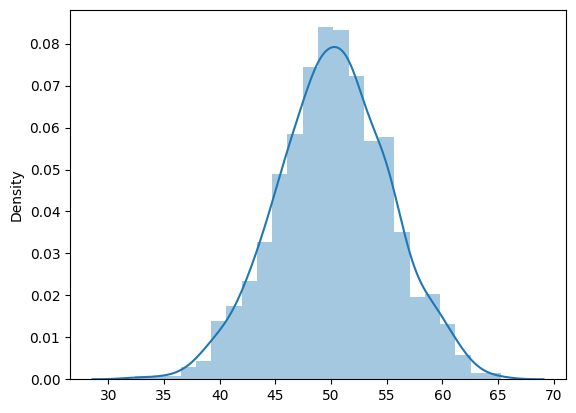

In [14]:
sns.distplot(sample)

#### KDE (Non - peramatreic Estimation)

In [15]:
sample1 = normal(loc=20, scale=5, size=300)
sample2 = normal(loc=40, scale=5, size=700)
sample = np.hstack((sample1, sample2))

sample

array([21.91355288, 18.28959829,  9.68624162, 17.73544548, 23.82878445,
       17.14337201, 17.92101852, 14.30780793, 19.77901436, 16.4171784 ,
       21.09039783, 32.33352828, 18.2429787 , 12.88802759, 20.80597321,
       23.81223719, 16.86619918, 17.56941117, 16.46509991, 27.670893  ,
       11.92103992, 20.13722556, 27.31259298, 17.98796171, 14.36014692,
       17.34197109, 15.61506822, 28.23020514, 24.56081704, 25.05682175,
       21.34717779, 21.10347012, 21.24942276, 20.80536551, 17.74364478,
       14.17166681,  8.84567676, 27.84585045, 20.86114518, 16.03533794,
       26.5771389 , 28.28515918, 24.29434054, 29.99238915, 21.87554721,
       17.75001145, 23.62986043, 17.90915011, 18.17257409, 17.97282685,
       16.82709094, 15.24611021, 19.36059005, 14.82950388, 17.01840808,
       19.80682763, 21.93158156, 20.81680795, 29.72966327, 16.05632695,
       19.46658268, 18.2739306 , 26.39517164, 20.86272963, 28.18492419,
       19.49945718, 21.80769619, 25.55977314,  7.09770887, 26.23

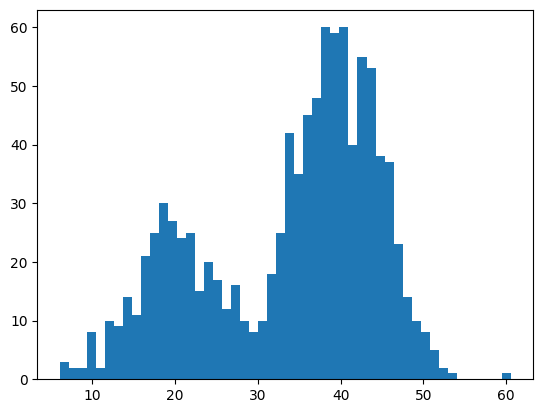

In [16]:
plt.hist(sample, bins=50);

In [17]:
from sklearn.neighbors import KernelDensity 
model = KernelDensity(bandwidth=3, kernel='gaussian')

# covert data to 2d array 
sample = sample.reshape((len(sample), 1))

model.fit(sample)

KernelDensity(bandwidth=3)

In [18]:
values = np.linspace(sample.min(), sample.max(), 100)
values = values.reshape((len(values), 1))

In [19]:
probabilites = model.score_samples(values)
probabilites = np.exp(probabilites)

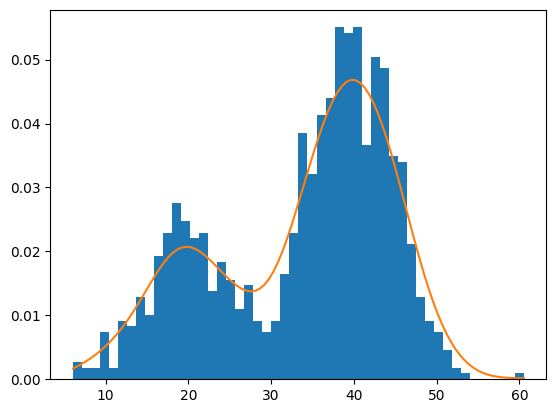

In [20]:
plt.hist(sample, bins=50, density=True)
plt.plot(values, probabilites)

<Axes: ylabel='Density'>

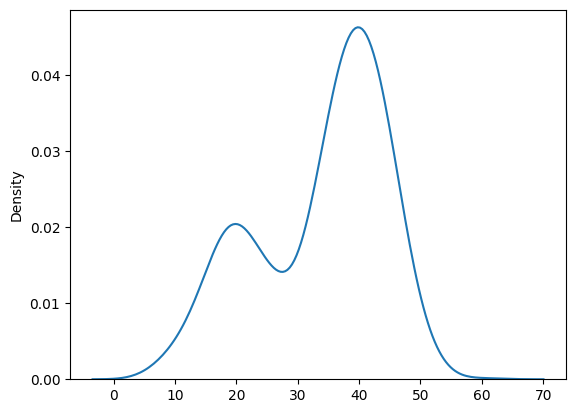

In [21]:
sns.kdeplot(sample.reshape(1000), bw_adjust=1.2)

#### Uses of PDF in Data Analysis

In [29]:
df = pd.read_csv('DataSets/iris.csv') # Here we want to keep only 2 feaures than, which 2 feaures should we keep

In [24]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


<Axes: xlabel='SepalLengthCm', ylabel='Density'>

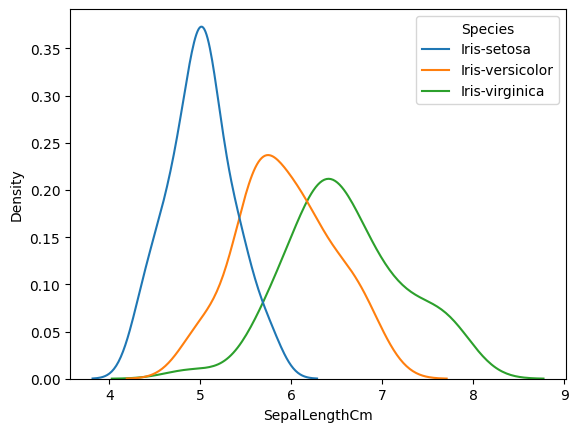

In [25]:
sns.kdeplot(data=df, x='SepalLengthCm', hue='Species')

<Axes: xlabel='SepalWidthCm', ylabel='Density'>

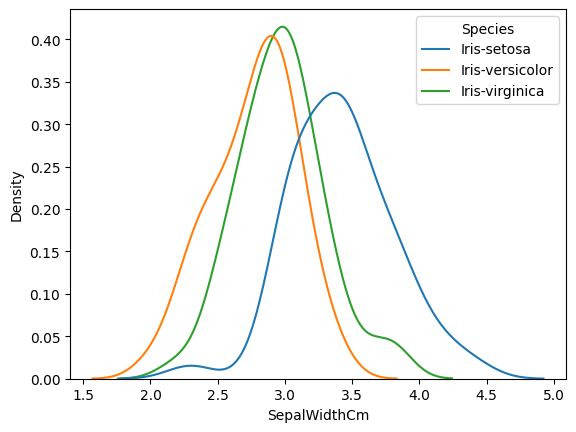

In [26]:
sns.kdeplot(data=df, x='SepalWidthCm', hue='Species')

<Axes: xlabel='PetalLengthCm', ylabel='Density'>

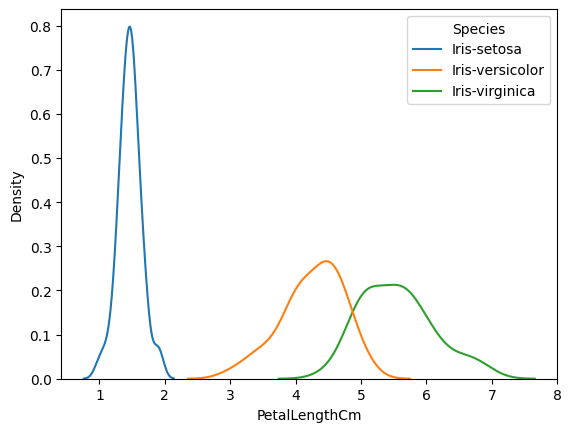

In [27]:
sns.kdeplot(data=df, x='PetalLengthCm', hue='Species')

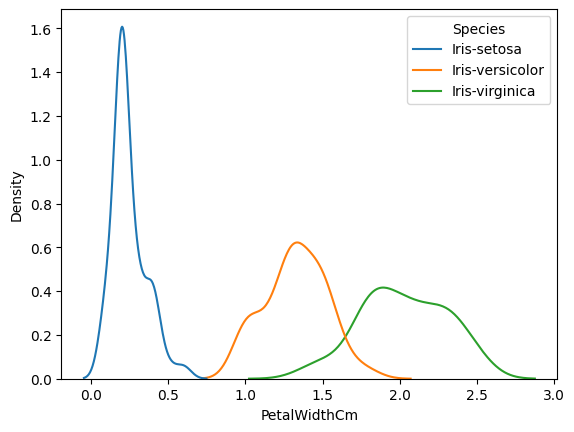

In [33]:
sns.kdeplot(data=df, x='PetalWidthCm', hue='Species');

In [35]:
print("So here we clear see the PetalLengthCm, PetalWidthCm graphs are more sepratly.")

So here we clear see the PetalLengthCm, PetalWidthCm graphs are more sepratly.


In [26]:
titanic = pd.read_csv('titanic.csv')
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

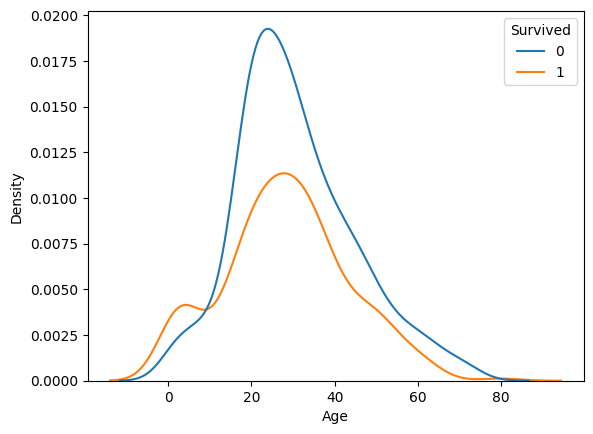

In [27]:
sns.kdeplot(data=titanic, x='Age', hue='Survived')

<Axes: xlabel='PetalWidthCm', ylabel='Density'>

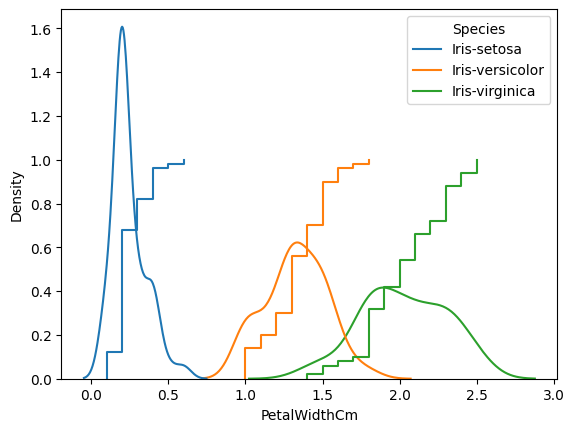

In [28]:
sns.kdeplot(data=df, x='PetalWidthCm', hue='Species')
sns.ecdfplot(data=df, x='PetalWidthCm', hue='Species')

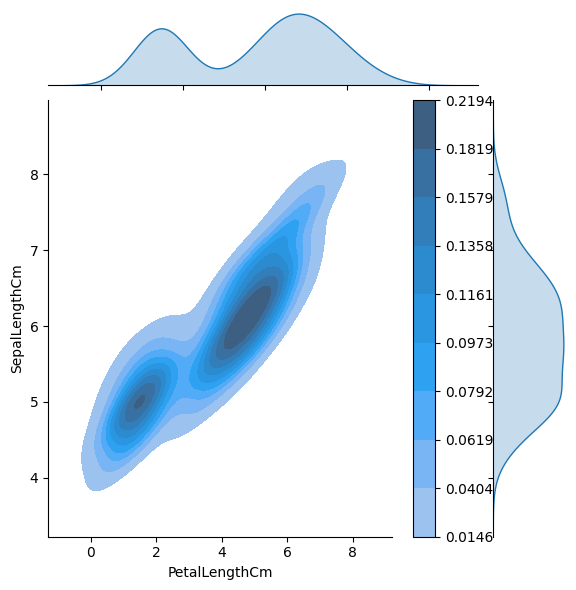

In [32]:
sns.jointplot(data=df, x='PetalLengthCm', y='SepalLengthCm', kind='kde', fill=True, cbar=True)

In [29]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


#### Standard Normal Variate
- special case of normal distribution
- in this the `mean=0` and `std=1`

In [33]:
titanic['Age']

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

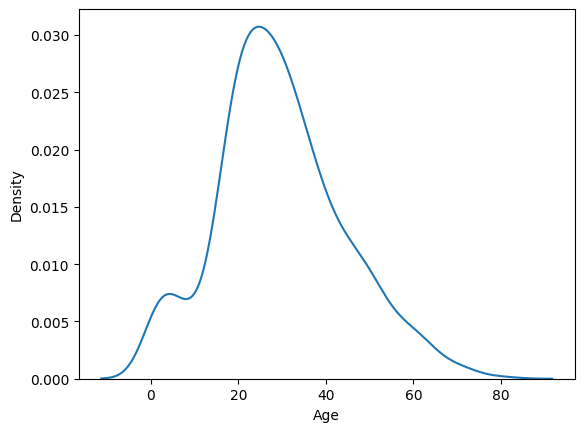

In [34]:
sns.kdeplot(data=titanic, x='Age')

In [38]:
titanic['Age'].mean()

np.float64(29.69911764705882)

In [36]:
titanic['Age'].std()

np.float64(14.526497332334042)

In [41]:
# convert this age into Standard Normal Variate
x = (titanic['Age'] - titanic['Age'].mean()) / titanic['Age'].std()
x

0     -0.530005
1      0.571430
2     -0.254646
3      0.364911
4      0.364911
         ...   
886   -0.185807
887   -0.736524
888         NaN
889   -0.254646
890    0.158392
Name: Age, Length: 891, dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

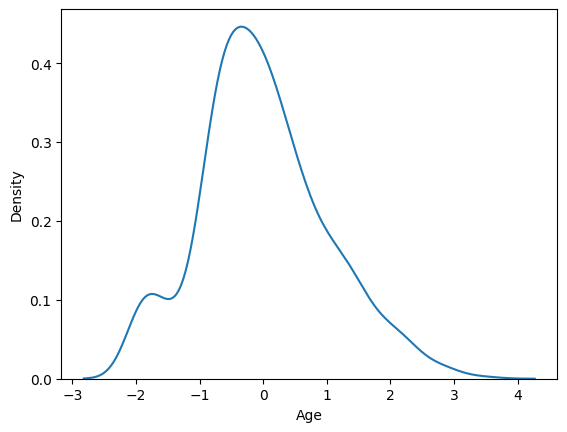

In [42]:
sns.kdeplot(x)

In [43]:
x.mean()

np.float64(2.338621049070358e-16)

In [44]:
x.std()

np.float64(1.0)

<Axes: >

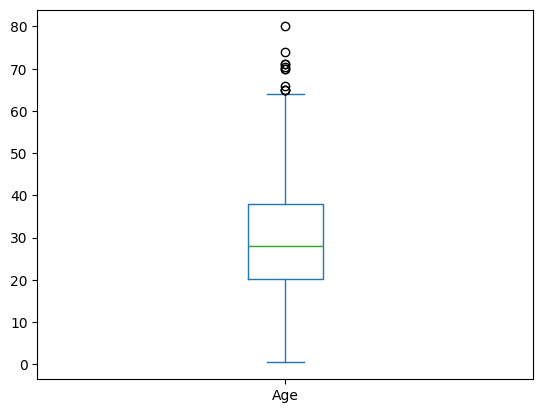

In [45]:
titanic['Age'].plot(kind='box')

In [ ]:
sns.displot()